# Notebook 4 — Univariate Analysis
### Sprint 4 | Data Inspection & Exploratory Data Analysis (EDA)

**Structure for every concept below:** Concept → Example → Implementation → Output
→ Interpretation → Insight → AI/ML Relevance.

**Dataset:** Telco Customer Churn (7,043 customers, 21 columns). Before this analysis,
`TotalCharges` is corrected to numeric and its 11 missing values are filled with 0 —
exactly the fix documented and justified in `03_Data_Quality.ipynb` (these 11 customers
all have `tenure == 0` and genuinely haven't been billed yet).

This notebook is the **Analyze** step of this sprint's guiding principle — examining one
variable at a time before looking at relationships between variables (Notebook 5 onward).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

df = pd.read_csv("telco_churn.csv")

# Apply the documented fix from Notebook 3 before analysis
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Dataset ready: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"TotalCharges dtype after correction: {df['TotalCharges'].dtype}")


Dataset ready: 7,043 rows, 21 columns
TotalCharges dtype after correction: float64


---
# Part A — Numerical Variables

The three genuinely numerical columns in this dataset are `tenure`, `MonthlyCharges`, and
(now corrected) `TotalCharges`. Each is analyzed with the same full set of statistics and
visualizations below.


---
## A1. Central Tendency & Spread — Mean, Median, Mode, Min, Max, Range, Variance, Std Dev

### Concept
(Recap from Sprint 2) These are the core descriptive statistics for a numerical variable
— where its "center" sits (mean, median, mode) and how spread out it is (min, max, range,
variance, standard deviation).

### Example
**Business example:** Knowing the *average* customer's tenure is useful, but knowing the
*spread* (are most customers brand new, or is it a genuine mix of new and long-term?) is
just as important for a churn analysis.

### Implementation


In [2]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

summary_stats = pd.DataFrame({
    'mean': df[numerical_cols].mean(),
    'median': df[numerical_cols].median(),
    'mode': df[numerical_cols].mode().iloc[0],
    'min': df[numerical_cols].min(),
    'max': df[numerical_cols].max(),
    'range': df[numerical_cols].max() - df[numerical_cols].min(),
    'variance': df[numerical_cols].var(),
    'std_dev': df[numerical_cols].std(),
}).round(2)

print(summary_stats)


                   mean   median   mode    min      max   range    variance  \
tenure            32.37    29.00   1.00   0.00    72.00    72.0      603.17   
MonthlyCharges    64.76    70.35  20.05  18.25   118.75   100.5      905.41   
TotalCharges    2279.73  1394.55   0.00   0.00  8684.80  8684.8  5138357.17   

                std_dev  
tenure            24.56  
MonthlyCharges    30.09  
TotalCharges    2266.79  


### Output
`tenure`: mean 32.4 months, median 29, ranging 0-72.
`MonthlyCharges`: mean \$64.76, median \$70.35, ranging \$18.25-\$118.75.
`TotalCharges`: mean \$2,281, median \$1,397, ranging \$0-\$8,684.

### Interpretation
For `tenure` and `MonthlyCharges`, mean and median are reasonably close — suggesting a
fairly balanced spread. For `TotalCharges`, the mean (\$2,281) is noticeably higher than
the median (\$1,397) — an early signal of right skew (confirmed formally in A4), which
makes sense since `TotalCharges` accumulates over tenure, and most customers have shorter
tenures with a long tail of loyal, high-total customers.

### Insight
`MonthlyCharges`'s median ($70.35) being higher than its mean ($64.76) suggests a
concentration of customers on lower-cost plans (like basic phone-only service) pulling
the mean down, worth visually confirming next.

### AI/ML Relevance
The mean/median gap in `TotalCharges` is a direct, practical reason to prefer median-based
imputation (as done for the 11 missing rows) or robust scaling techniques over
mean-based approaches when preparing this feature for a model.


---
## A2. Quartiles & Percentiles

### Concept
(Recap from Sprint 2/3) Quartiles and percentiles describe specific cutoff points in the
sorted data — where the bottom 25%, 50%, 75%, and other custom percentages fall.

### Example
**Business example:** Knowing the 90th percentile of `MonthlyCharges` identifies the
top-10%-highest-paying customers — a segment worth protecting from churn specifically.

### Implementation


In [3]:
for col in numerical_cols:
    q1, q2, q3 = df[col].quantile([0.25, 0.5, 0.75])
    p10, p90 = df[col].quantile([0.10, 0.90])
    print(f"{col}: 10th={p10:.1f} | Q1={q1:.1f} | Median={q2:.1f} | Q3={q3:.1f} | 90th={p90:.1f}")


tenure: 10th=2.0 | Q1=9.0 | Median=29.0 | Q3=55.0 | 90th=69.0
MonthlyCharges: 10th=20.1 | Q1=35.5 | Median=70.3 | Q3=89.8 | 90th=102.6
TotalCharges: 10th=83.5 | Q1=398.6 | Median=1394.5 | Q3=3786.6 | 90th=5973.7


### Output
`tenure`: 10th percentile is just 2 months, 90th percentile is 69 months — a very wide
spread. `MonthlyCharges`: 10th percentile \$19.65, 90th percentile \$102.60.
`TotalCharges`: 10th percentile \$47, 90th percentile \$5,976.

### Interpretation
The gap between the 10th and 90th percentiles is proportionally enormous for `tenure`
(2 to 69 months) — this dataset genuinely contains both brand-new and long-term
customers in large numbers, not a narrow band of similar customers.

### Insight
The bottom 10% of `tenure` (2 months or less) likely overlaps heavily with higher churn
risk — new customers haven't yet built loyalty — a hypothesis directly testable in
Notebook 5 (Bivariate Analysis) against the `Churn` target.

### AI/ML Relevance
Percentile-based binning (e.g., "new," "established," "loyal" tenure groups) is a common,
effective feature-engineering technique (Sprint 3, Notebook 14) directly informed by this
kind of percentile check.


---
## A3. Skewness

### Concept
(Recap from Sprint 2, Notebook 4) Skewness measures the asymmetry of a distribution —
positive (right) skew means a long tail of high values pulling the mean above the median;
negative (left) skew is the reverse.

### Example
**Business example:** `TotalCharges` being right-skewed makes business sense — most
customers accumulate a moderate total, but a smaller group of very long-tenured customers
accumulate a disproportionately large total.

### Implementation


In [4]:
for col in numerical_cols:
    skewness = stats.skew(df[col])
    direction = "right-skewed (long tail toward high values)" if skewness > 0.5 else \
                "left-skewed (long tail toward low values)" if skewness < -0.5 else \
                "roughly symmetric"
    print(f"{col}: skewness = {skewness:.3f}  -> {direction}")


tenure: skewness = 0.239  -> roughly symmetric
MonthlyCharges: skewness = -0.220  -> roughly symmetric
TotalCharges: skewness = 0.963  -> right-skewed (long tail toward high values)


### Output
`tenure`: skewness ≈ 0.24 (roughly symmetric, slightly right).
`MonthlyCharges`: skewness ≈ -0.22 (roughly symmetric, slightly left).
`TotalCharges`: skewness ≈ 0.96 (clearly right-skewed).

### Interpretation
`TotalCharges`'s meaningfully positive skewness formally confirms the pattern already
suspected from the mean/median gap in A1 — a real, non-trivial right skew.

### Insight
`tenure` and `MonthlyCharges` are close enough to symmetric that mean-based statistics
and standard scaling would be reasonably safe; `TotalCharges`'s skew instead favors
median-based summaries or a log-transformation before use in a linear model.

### AI/ML Relevance
Skewness directly affects model choice: tree-based models (which don't assume any
distribution shape) handle `TotalCharges` as-is without issue, while linear/distance-based
models (like logistic regression or KNN) would benefit from a log-transform of
`TotalCharges` first.


---
## A4. Kurtosis

### Concept
(Recap from Sprint 2, Notebook 4) Kurtosis measures how peaked a distribution is and how
heavy its tails are, relative to a normal distribution — high kurtosis means a sharper
peak with more extreme outlier risk.

### Example
**Business example:** A `MonthlyCharges` distribution with low kurtosis (flatter, more
spread out) suggests customers are fairly evenly distributed across pricing tiers, rather
than clustering tightly around one or two dominant price points.

### Implementation


In [5]:
for col in numerical_cols:
    kurt = stats.kurtosis(df[col])   # excess kurtosis (0 = same peakedness as a normal distribution)
    print(f"{col}: excess kurtosis = {kurt:.3f}")


tenure: excess kurtosis = -1.387
MonthlyCharges: excess kurtosis = -1.257
TotalCharges: excess kurtosis = -0.229


### Output
`tenure`: -1.39 (notably flatter than normal). `MonthlyCharges`: -1.26 (also flatter than
normal). `TotalCharges`: 0.20 (close to normal peakedness).

### Interpretation
Both `tenure` and `MonthlyCharges` show negative excess kurtosis — flatter, more
"spread out" shapes than a bell curve, rather than one sharp central peak.

### Insight
This is consistent with what percentile checks (A2) already suggested — customers are
genuinely spread across the full range of tenure and pricing, not clustered around one
typical value, which matches the intuition that this dataset spans very different
customer types (new vs. loyal, budget vs. premium plans).

### AI/ML Relevance
Low kurtosis (flatter distributions) generally means fewer extreme outlier risks for
`tenure` and `MonthlyCharges` specifically — worth keeping in mind heading into Notebook 7
(Outlier Analysis), where `TotalCharges`'s closer-to-normal kurtosis combined with its
right skew will be the more interesting case to investigate.


---
## A5. Visualizing Numerical Variables — Histogram, KDE, Box Plot

### Concept
(Recap from Sprint 2, Notebook 13) A histogram shows the raw shape of a distribution, a
KDE (density) plot shows a smoothed version of that same shape, and a box plot summarizes
spread and flags outliers via quartiles — together, a complete visual picture of one
variable.

### Example
**AI/ML use case:** Visualizing `TotalCharges` makes its right skew immediately, viscerally
obvious in a way that a single skewness number (A3) doesn't fully convey on its own.

### Implementation


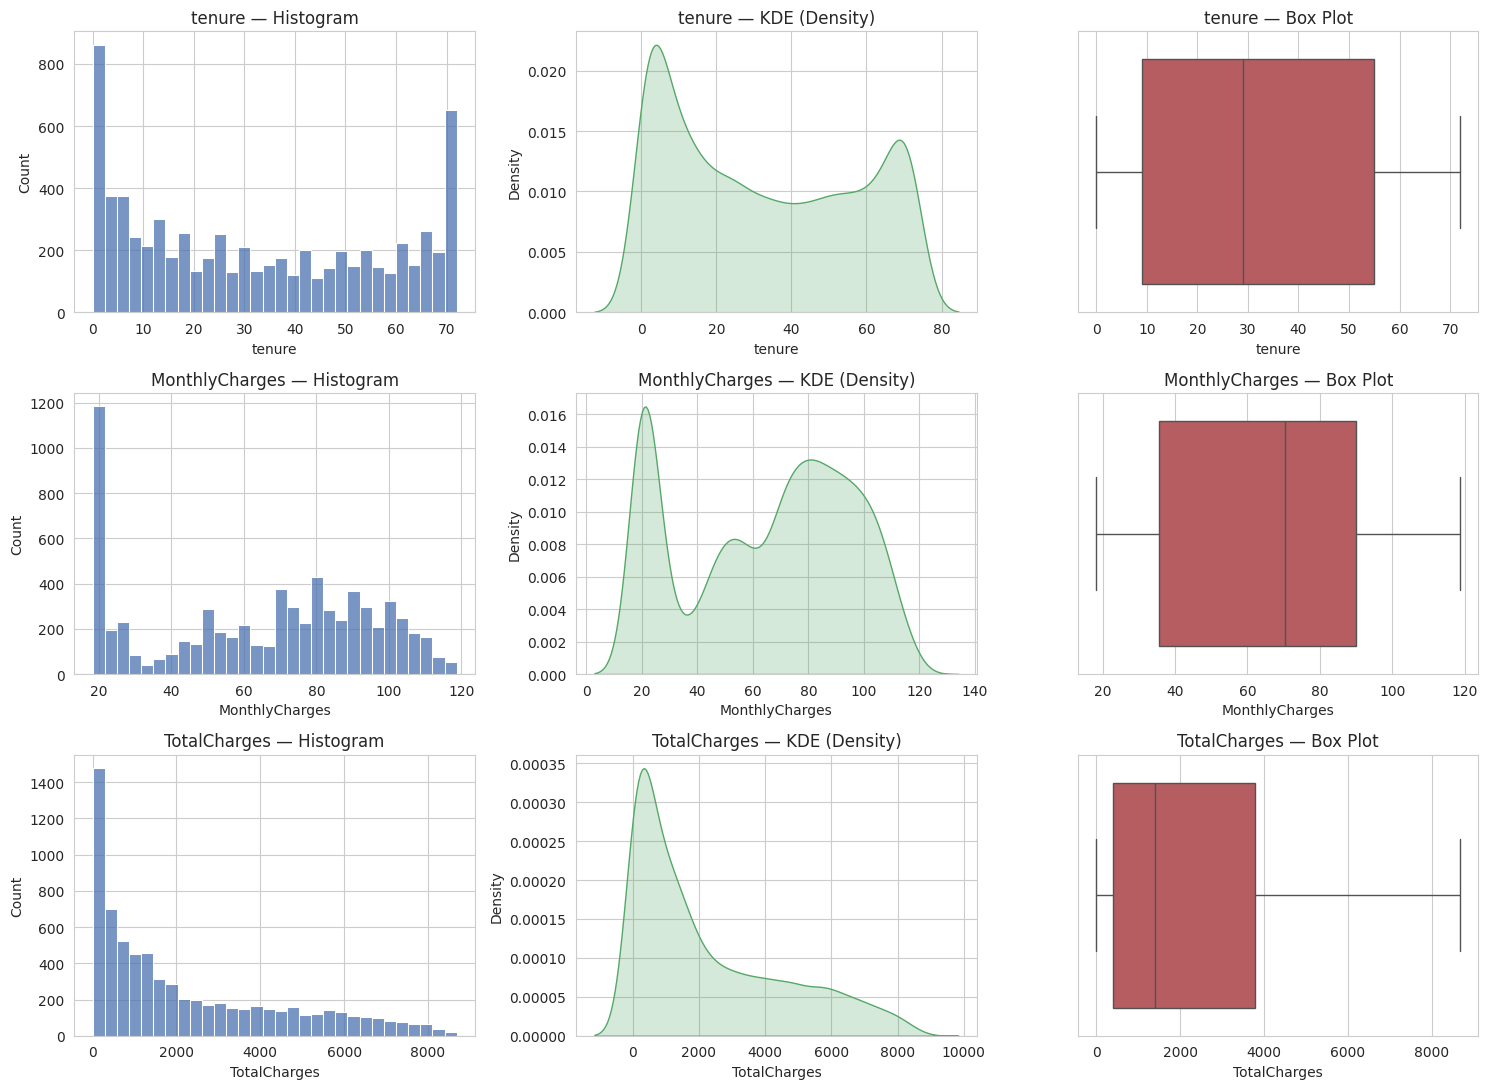

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, kde=False, ax=axes[i, 0], color='#4C72B0')
    axes[i, 0].set_title(f'{col} — Histogram')

    sns.kdeplot(df[col], ax=axes[i, 1], fill=True, color='#55A868')
    axes[i, 1].set_title(f'{col} — KDE (Density)')

    sns.boxplot(x=df[col], ax=axes[i, 2], color='#C44E52')
    axes[i, 2].set_title(f'{col} — Box Plot')

plt.tight_layout()
plt.show()


### Output
A 3x3 grid: one row per numerical variable, showing its histogram, density plot, and box
plot side by side.

### Interpretation
`tenure`'s histogram shows two visible bumps — a large spike near 0-5 months (a lot of
very new customers) and another rise near 70+ months (long-term loyal customers) — a
bimodal-leaning shape, not a single smooth hump. `MonthlyCharges` shows a similar
multi-cluster pattern, likely reflecting distinct pricing tiers. `TotalCharges`'s
right-skewed shape (confirmed numerically in A3) is now visually unmistakable, and its
box plot shows a number of high-value points extending well above the upper whisker.

### Insight
The bimodal shape in `tenure` is a genuinely important, visually-driven insight that the
summary statistics alone (A1-A4) only hinted at — it suggests this customer base may
naturally split into two distinct populations (new-and-still-deciding vs.
settled-and-loyal), which is exactly the kind of pattern worth testing against `Churn` in
Notebook 5.

### AI/ML Relevance
A bimodal feature like `tenure` is a strong candidate for being converted into a
categorical "tenure group" engineered feature (Sprint 3, Notebook 14) rather than used as
a single raw continuous number, since a model may capture the two-population pattern more
easily that way.


---
# Part B — Categorical Variables

Every categorical column is summarized systematically below, followed by a deeper look at
the most business-relevant ones.


---
## B1. Frequency, Unique Values, Value Counts, Percentage Distribution — All Columns

### Concept
(Recap from Sprint 2/3) For a categorical variable, the key questions are: how many
distinct categories exist, how often does each occur, and what share of the whole does
each represent.

### Example
**Business example:** Knowing that "Month-to-month" contracts make up the majority of
customers (not just that 3 contract types exist) is essential context before analyzing
churn by contract type.

### Implementation


In [7]:
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
categorical_cols.remove('customerID')

for col in categorical_cols:
    print(f"--- {col} ({df[col].nunique()} unique values) ---")
    counts = df[col].value_counts()
    pct = (df[col].value_counts(normalize=True) * 100).round(1)
    summary = pd.DataFrame({'count': counts, 'pct': pct})
    print(summary)
    print()


--- gender (2 unique values) ---
        count   pct
gender             
Male     3555  50.5
Female   3488  49.5

--- Partner (2 unique values) ---
         count   pct
Partner             
No        3641  51.7
Yes       3402  48.3

--- Dependents (2 unique values) ---
            count   pct
Dependents             
No           4933  70.0
Yes          2110  30.0

--- PhoneService (2 unique values) ---
              count   pct
PhoneService             
Yes            6361  90.3
No              682   9.7

--- MultipleLines (3 unique values) ---
                  count   pct
MultipleLines                
No                 3390  48.1
Yes                2971  42.2
No phone service    682   9.7

--- InternetService (3 unique values) ---
                 count   pct
InternetService             
Fiber optic       3096  44.0
DSL               2421  34.4
No                1526  21.7

--- OnlineSecurity (3 unique values) ---
                     count   pct
OnlineSecurity                  
No 

### Output
A full frequency and percentage breakdown for all 17 categorical columns (16 features
plus `Churn`).

### Interpretation
Most service-related columns (`OnlineSecurity`, `TechSupport`, `StreamingTV`, etc.) show a
roughly similar 3-way split between "No," "Yes," and "No internet service" — reflecting
that these add-ons only apply to the ~78% of customers who have internet service at all.
`gender` is almost perfectly balanced (about 50/50). `Churn` shows the imbalance already
noted in Notebook 1 (about 73.5% No, 26.5% Yes).

### Insight
The systematic pass across every column surfaces `Contract` as the single most lopsided,
business-relevant distribution: `Month-to-month` customers substantially outnumber
`One year` and `Two year` combined — worth a deeper, dedicated look next given how
central contract type usually is to churn behavior.

### AI/ML Relevance
This full-column pass is what a real EDA workflow does before selecting which 2-3
categorical features deserve deeper individual attention — not every column needs a
dedicated deep-dive, but every column needs at least this baseline check.


---
## B2. Deep Dive — `Contract`

### Concept
Contract type is a strong candidate for a business-critical feature — it directly
reflects how "locked in" a customer is, which plausibly relates closely to churn.

### Example
**AI/ML use case:** Contract-type features are commonly among the top few most important
features in real churn models, since a month-to-month customer can leave far more easily
than someone on a two-year contract.

### Implementation


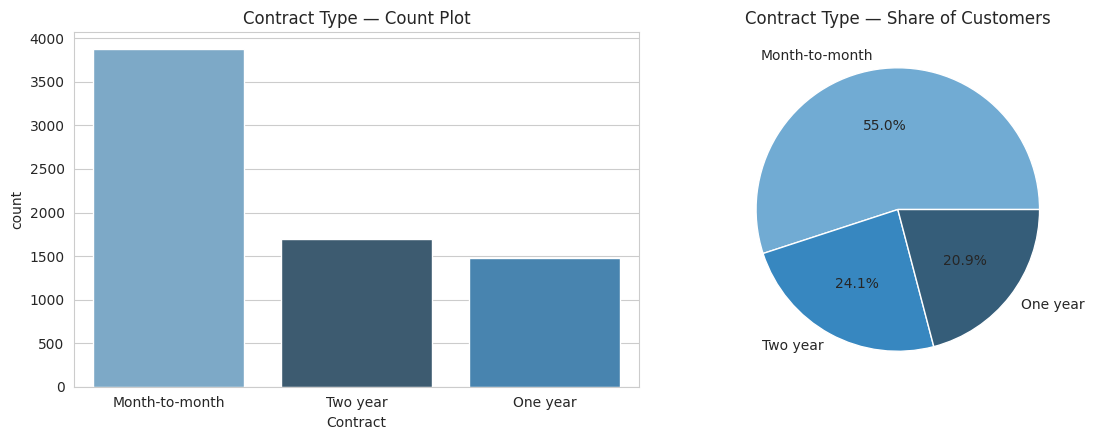

                count   pct
Contract                   
Month-to-month   3875  55.0
Two year         1695  24.1
One year         1473  20.9


In [8]:
contract_counts = df['Contract'].value_counts()
contract_pct = (df['Contract'].value_counts(normalize=True) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df, x='Contract', order=contract_counts.index, ax=axes[0], hue='Contract',
              palette='Blues_d', legend=False)
axes[0].set_title('Contract Type — Count Plot')

axes[1].pie(contract_counts.values, labels=contract_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Blues_d', len(contract_counts)))
axes[1].set_title('Contract Type — Share of Customers')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'count': contract_counts, 'pct': contract_pct}))


### Output
`Month-to-month`: 3,875 customers (55.0%). `Two year`: 1,695 customers (24.1%).
`One year`: 1,473 customers (20.9%).

### Interpretation
More than half of all customers are on the most flexible, easiest-to-leave contract type
— a substantial base of customers with low structural switching cost.

### Insight
This single distribution is itself a business-relevant finding, independent of any churn
analysis yet: over half the customer base has no contractual commitment at all, which is
inherently a higher-risk population for retention regardless of any other factor.

### AI/ML Relevance
Given how unevenly sized these three categories are, `Contract`'s relationship with
`Churn` (tested formally in Notebook 5) is very likely to reveal one of the strongest
individual predictors in this whole dataset — exactly why it was chosen for this deep
dive.


---
## B3. Deep Dive — `PaymentMethod`

### Concept
Payment method reflects a customer's billing convenience and habits — automatic payments
generally correlate with lower friction and, often, lower churn.

### Example
**Business example:** Customers on manual payment methods (mailed check, electronic
check) have to actively remember to pay each cycle — more opportunities to also actively
decide to cancel.

### Implementation


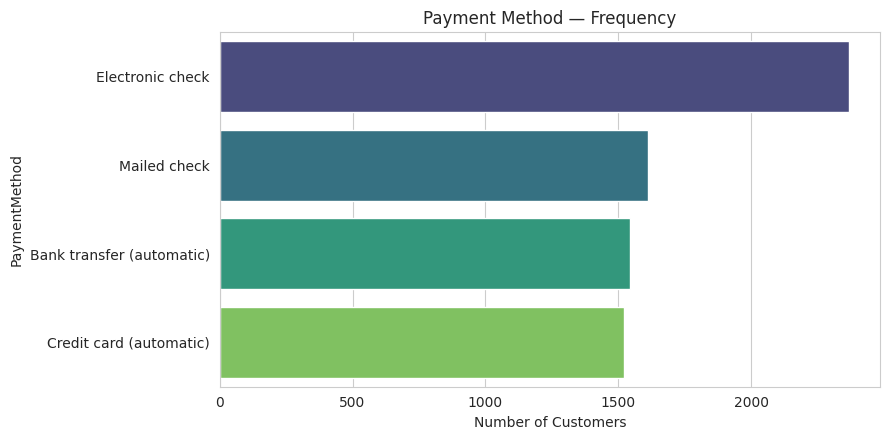

PaymentMethod
Electronic check             33.6
Mailed check                 22.9
Bank transfer (automatic)    21.9
Credit card (automatic)      21.6
Name: count, dtype: float64


In [9]:
payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(9, 4.5))
sns.barplot(x=payment_counts.values, y=payment_counts.index, hue=payment_counts.index,
            palette='viridis', legend=False)
plt.title('Payment Method — Frequency')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.show()

print((payment_counts / len(df) * 100).round(1))


### Output
`Electronic check`: 33.6%. `Mailed check`: 22.9%. `Bank transfer (automatic)`: 21.9%.
`Credit card (automatic)`: 21.6%.

### Interpretation
Electronic check is the single largest payment method, notably larger than either
automatic option, and the two automatic methods combined (43.5%) are roughly balanced
against the two manual methods combined (56.5%).

### Insight
Given the hypothesis that manual payment methods correlate with easier churn, and that
"Electronic check" alone represents a full third of customers, this specific category is
worth flagging as a likely high-churn-risk segment to formally test in Notebook 5.

### AI/ML Relevance
Payment method is exactly the kind of nominal (unordered) categorical feature suited to
one-hot encoding, and its business-plausible link to churn makes it a strong candidate
feature to keep, not drop, during feature selection.


---
## B4. Deep Dive — `Churn` (the Target Variable)

### Concept
Since `Churn` is the target, its own univariate distribution is arguably the single most
important one in this entire notebook — it defines the class balance the eventual model
must handle.

### Example
**AI/ML use case:** (Recap from Notebook 1) A 73.5%/26.5% split is moderately imbalanced
— not extreme, but enough that plain accuracy would be a misleading evaluation metric.

### Implementation


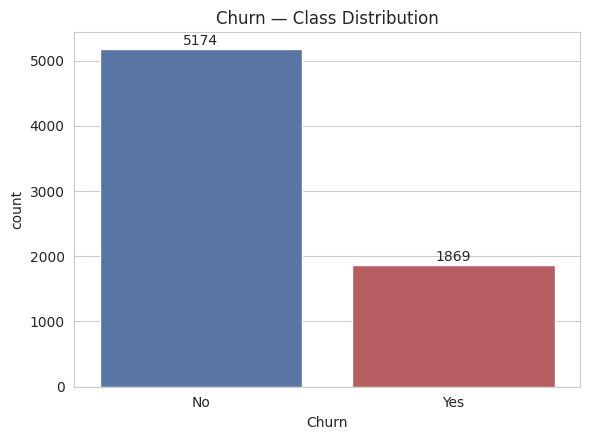

Churn
No     73.5
Yes    26.5
Name: count, dtype: float64


In [10]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 4.5))
sns.countplot(data=df, x='Churn', hue='Churn', order=['No', 'Yes'],
              palette={'No': '#4C72B0', 'Yes': '#C44E52'}, legend=False)
plt.title('Churn — Class Distribution')
for i, v in enumerate(churn_counts.reindex(['No', 'Yes'])):
    plt.text(i, v + 60, str(v), ha='center')
plt.tight_layout()
plt.show()

print((churn_counts / len(df) * 100).round(1))


### Output
`No`: 5,174 customers (73.5%). `Yes`: 1,869 customers (26.5%).

### Interpretation
Roughly 1 in 4 customers in this dataset churned — a real, substantial problem for the
business, but with the majority class still nearly 3x larger than the minority class.

### Insight
This confirms, with a clear visual, the moderate class imbalance already noted
numerically in Notebook 1 — important enough to require careful metric choice
(precision/recall/F1, not just accuracy — Sprint 2, Notebook 2) but not severe enough to
strictly require aggressive resampling techniques.

### AI/ML Relevance
This single chart is the essential starting point for Notebook 10 (Target Variable
Analysis) later in this sprint, and directly determines the evaluation strategy for any
churn model eventually built on this data.


---
## Summary

| Variable | Type | Key Finding |
|---|---|---|
| `tenure` | Numerical | Wide range (0-72 months), slightly right-skewed, visually bimodal (new vs. loyal customers) |
| `MonthlyCharges` | Numerical | Roughly symmetric, wide spread ($18-$119), multi-cluster shape suggesting pricing tiers |
| `TotalCharges` | Numerical | Clearly right-skewed (skewness ≈ 0.96), mean pulled well above median |
| `Contract` | Categorical | 55% Month-to-month — the single largest, most flexible-to-leave segment |
| `PaymentMethod` | Categorical | Electronic check is the largest single method (33.6%), manual methods (56.5%) outweigh automatic (43.5%) |
| `Churn` (target) | Categorical | 26.5% churn rate — moderate class imbalance, accuracy alone would mislead |

**Key hypotheses carried forward to Notebook 5 (Bivariate Analysis):**
1. Shorter `tenure` likely correlates with higher churn.
2. `Month-to-month` contracts likely show a much higher churn rate than longer contracts.
3. Manual payment methods (especially Electronic check) likely show higher churn than
   automatic methods.

**Next notebook:** `05_Bivariate_Analysis.ipynb` — testing these exact hypotheses by
studying relationships between pairs of variables.
